# Gene Expression Peak-Trough analysis using Polar Plots

April 8, 2024

Analyze the chromatin at genes during peak and trough gene expression.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

# Compute replication profile for each gene

For each gene
1. Compute the raw replication profile
2. Compute its replication time (early/late)
3. Will need to normalize by the replicate's S phase
4. Compute the correlation with its gene expression


In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [4]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

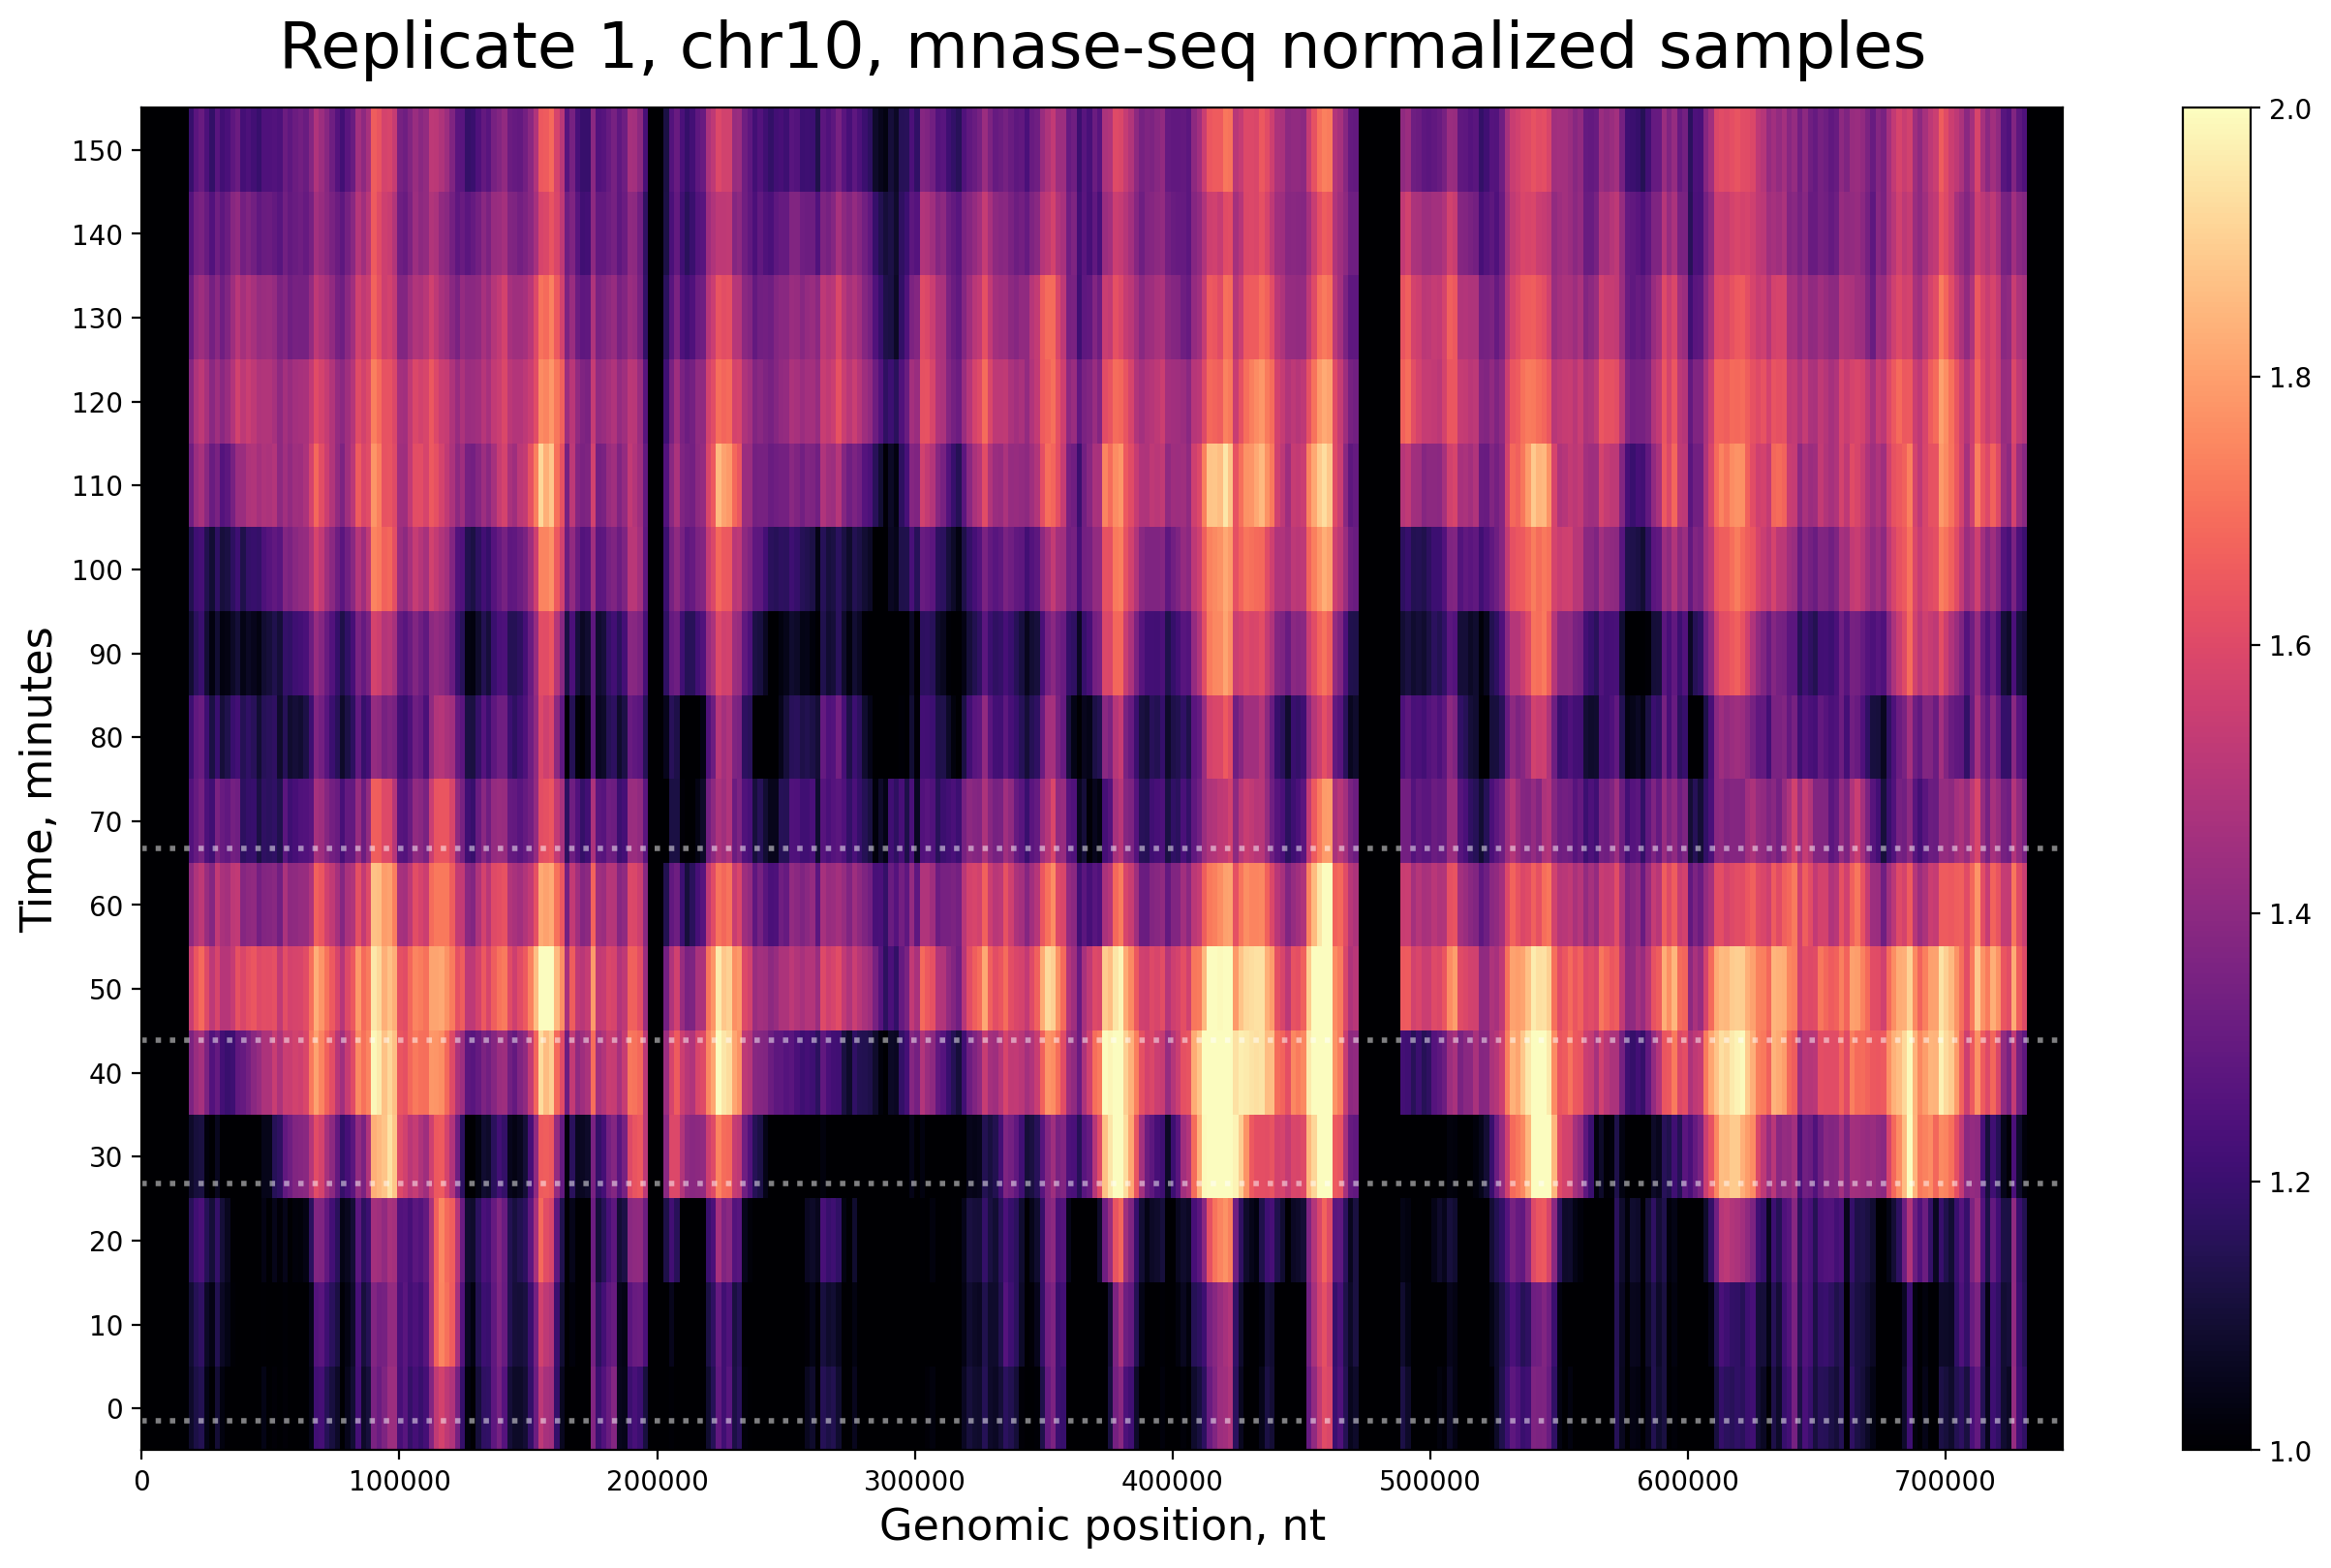

In [6]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

# Compute replication timing profile for both replicates

Compute the 10k bin curves for all genes, normalize the occupancy within the first cell cycle length, then compute the time in which the occupancy reaches a specified threshold (currently 75%) for each gene. The time in which this threshold is met is the replication timing.

Perform for both genes, compute the correlation and take the average.


In [141]:
mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.915


In [142]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep2.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:22.560


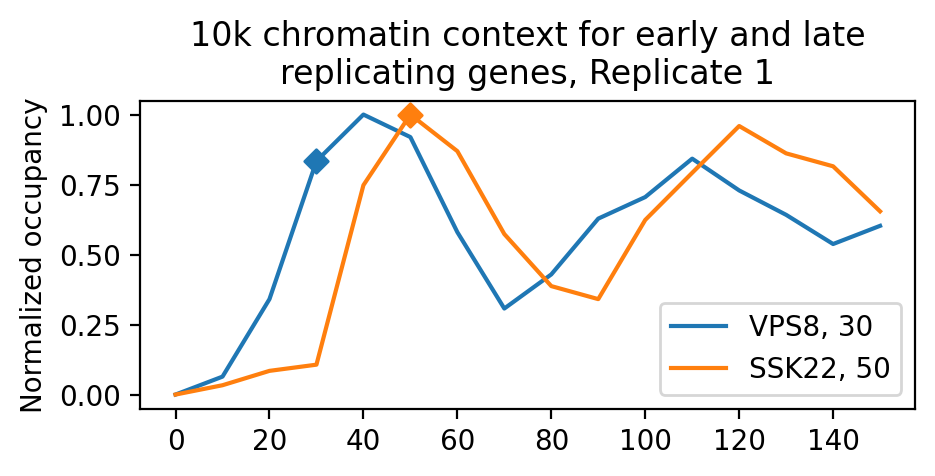

In [301]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

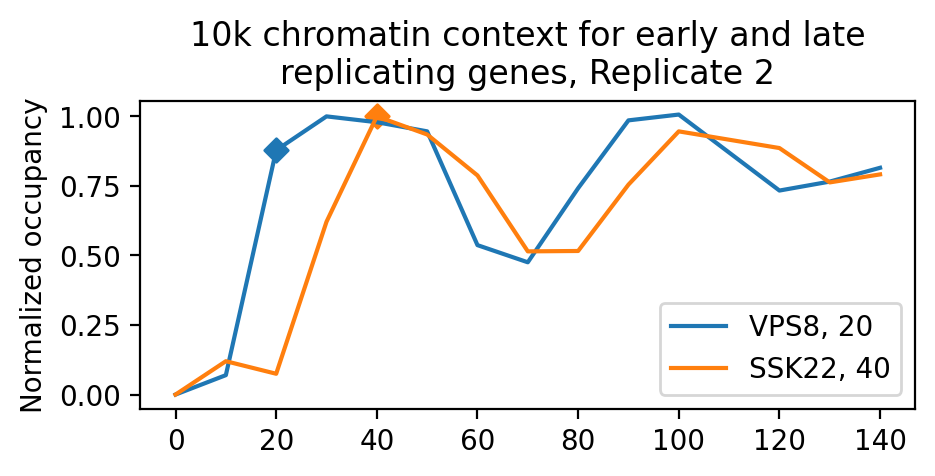

In [302]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [224]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

In [238]:
# We have where G1 should start (w/o recovery) and the length of the cell cycle
# so let's normalize based on translating to the that G1 start
# then divide by the cell cycle length

mnase_analysis_rep1.normalize_replication_timing_by_cell_cycle_parameters()
mnase_analysis_rep2.normalize_replication_timing_by_cell_cycle_parameters()

Text(0.5, 0.98, 'Distribution of replication timing')

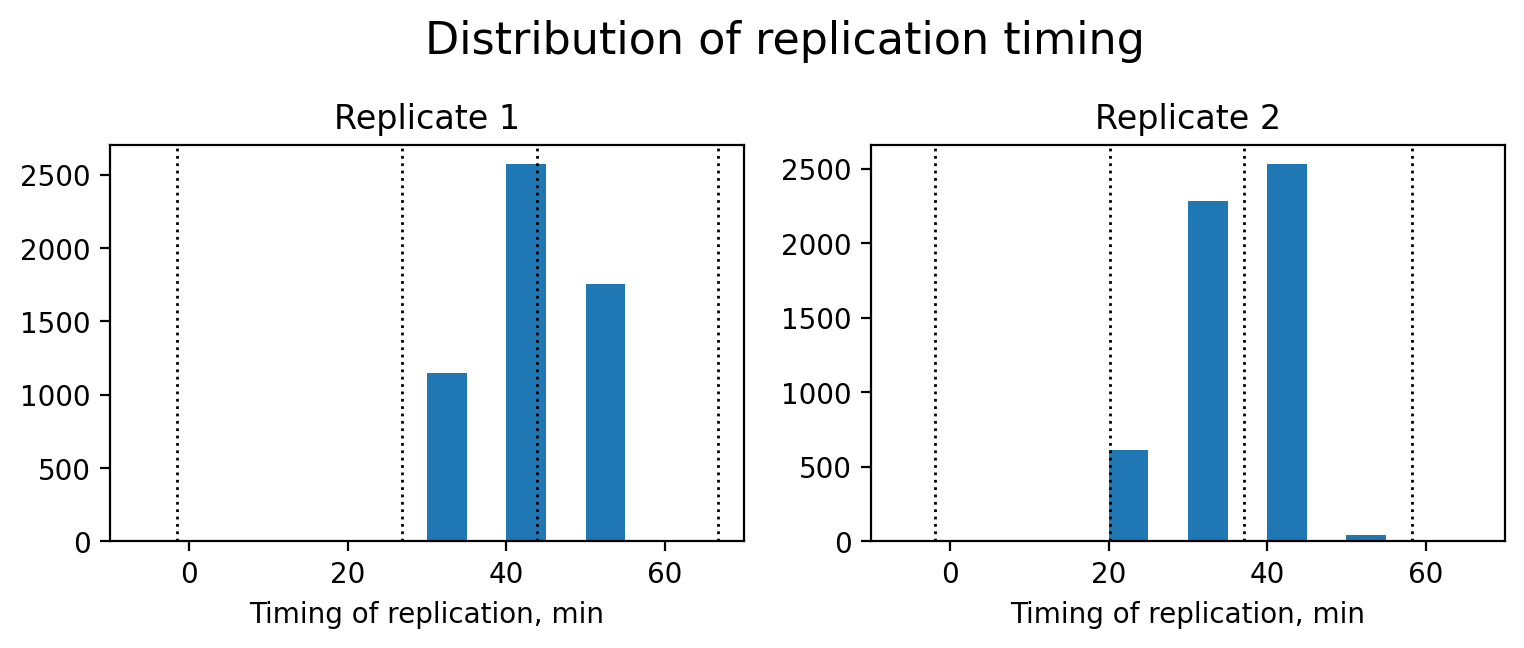

In [303]:
bins = np.arange(0, 70, 5)-5

plt.figure(figsize=(9, 3))
plt.subplots_adjust(top=0.77)

plt.subplot(1, 2, 1)
plt.hist(mnase_analysis_rep1.repl_timing_df, bins=bins)

def plot_lines(lines):
    for line in lines:
        plt.axvline(line, c='black', lw=1, ls='dotted')

plot_lines([
    mnase_analysis_rep1.g1_recovery_would_start_here,
    mnase_analysis_rep1.first_s_start,
    mnase_analysis_rep1.first_s_end,
    mnase_analysis_rep1.end_of_first_lambd,
])

plt.xlim(-10, 70)
plt.title("Replicate 1")
plt.xlabel("Timing of replication, min")

plt.subplot(1, 2, 2)
plt.hist(mnase_analysis_rep2.repl_timing_df, bins=bins)

plot_lines([
    mnase_analysis_rep2.g1_recovery_would_start_here,
    mnase_analysis_rep2.first_s_start,
    mnase_analysis_rep2.first_s_end,
    mnase_analysis_rep2.end_of_first_lambd,
])

plt.xlim(-10, 70)
plt.title("Replicate 2")
plt.xlabel("Timing of replication, min")

plt.suptitle("Distribution of replication timing", fontsize=16)

In [262]:
merged_replication_timing = pd.DataFrame(mnase_analysis_rep1.normalized_timing, columns=['repl_timing1']).join(
    pd.DataFrame(mnase_analysis_rep2.normalized_timing, columns=['repl_timing2']))
merged_replication_timing['mean'] = merged_replication_timing.mean(axis=1)

([], [])

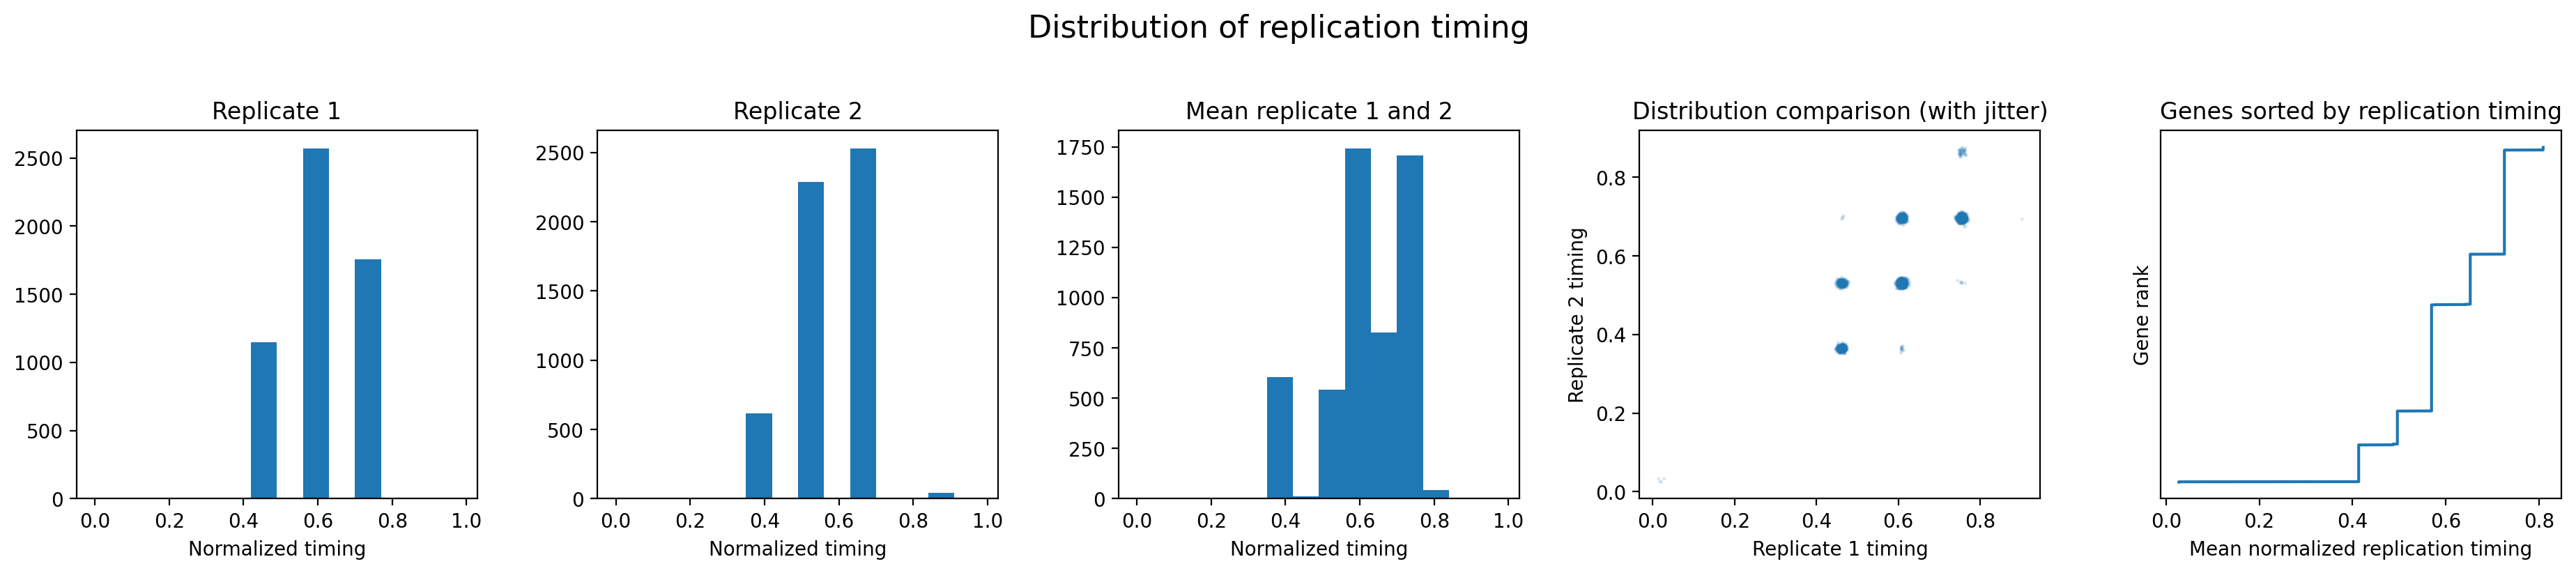

In [308]:

bins = np.arange(0, 1, 0.07)

plt.figure(figsize=(23, 4))
plt.subplots_adjust(top=0.77, wspace=0.3)

plt.subplot(1, 5, 1)
plt.hist(merged_replication_timing.repl_timing1, bins=bins)
plt.title("Replicate 1")
plt.xlabel("Normalized timing")

plt.subplot(1, 5, 2)
plt.hist(merged_replication_timing.repl_timing2, bins=bins)
plt.title("Replicate 2")
plt.xlabel("Normalized timing")

plt.subplot(1, 5, 3)
plt.hist(merged_replication_timing['mean'], bins=bins)
plt.title("Mean replicate 1 and 2")
plt.xlabel("Normalized timing")

plt.suptitle("Distribution of replication timing", fontsize=16)

plt.subplot(1, 5, 4)
from scipy.stats.distributions import norm

n = len(merged_replication_timing)
x_jitter = norm.rvs(loc=0, scale=0.005, size=n)
y_jitter = norm.rvs(loc=0, scale=0.005, size=n)

plt.scatter(merged_replication_timing.repl_timing1 + x_jitter, 
            merged_replication_timing.repl_timing2 + y_jitter,
           s=1, alpha=0.1)
plt.xlabel("Replicate 1 timing")
plt.ylabel("Replicate 2 timing")
plt.title("Distribution comparison (with jitter)")

plt.subplot(1, 5, 5)
x = np.arange(n)
plt.plot(merged_replication_timing.sort_values('mean')['mean'], x)
plt.title("Genes sorted by replication timing")
plt.xlabel("Mean normalized replication timing")
plt.ylabel("Gene rank")
plt.yticks([])

In [282]:
merged_replication_timing.to_csv('datasets/computed_mnase/replication_timing_10k.csv')